In [22]:
# LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from pydub import AudioSegment
from google.colab import drive
drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/Sesiones_Fourier_Nota_CM_piano.mp3"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
audio = AudioSegment.from_mp3(ruta)

# Convertir audio a arreglo NumPy
y = np.array(audio.get_array_of_samples())

# Si el audio es estéreo, tomar solamente un canal
if audio.channels == 2:
    y = y.reshape((-1,2))
    y = y[:,0]

# Frecuencia de muestreo
fs = audio.frame_rate

x = np.arange(len(y))/fs

print("Frecuencia de muestreo =", fs, "Hz")
print("Número de muestras =", len(y))

Frecuencia de muestreo = 44100 Hz
Número de muestras = 152064


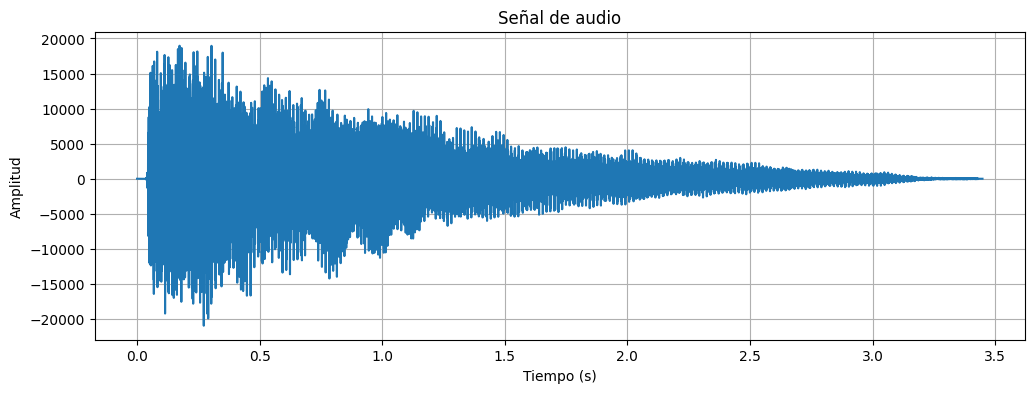

In [29]:
plt.figure(figsize=(12,4))
plt.plot(x,y)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal de audio")
plt.grid()

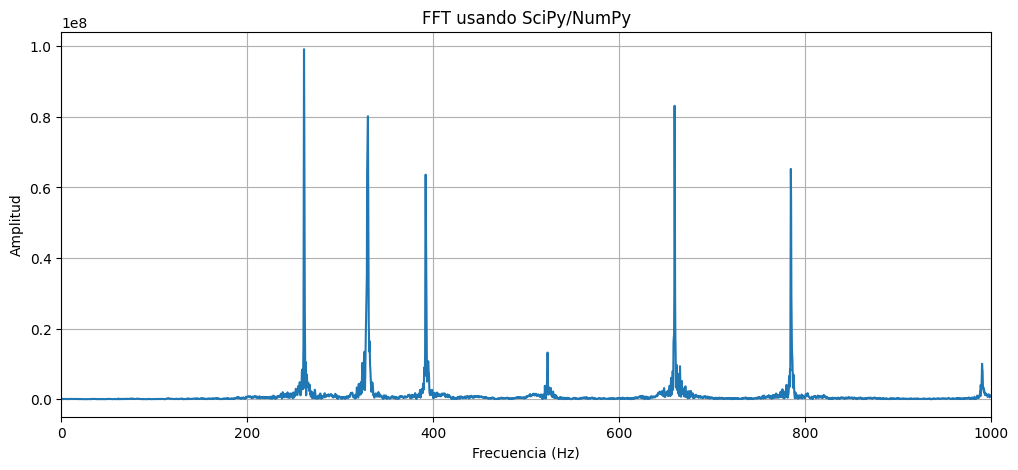

In [31]:
# FFT USANDO SCIPY / NUMPY
N = len(y)

# Transformada rápida de Fourier
Y = fft(y)

freq = fftfreq(N,1/fs)

# Solo frecuencias positivas
mask = freq >= 0

plt.figure(figsize=(12,5))

plt.plot(freq[mask],np.abs(Y[mask]))

plt.xlim(0,1000)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("FFT usando SciPy/NumPy")
plt.grid()

Rutina de Clase modificada

In [41]:
# RUTINA FFT MODIFICADA
# para adaptarla a una señal digital.


def FT(x,y):

    # Paso temporal
    dt = x[1]-x[0]

    # Frecuencias a analizar
    f = np.linspace(20,2000,500)

    datos = []

    for fi in f:

        F = np.sum(
            y*np.exp(-1j*2*np.pi*fi*x)
        )*dt

        datos.append([
            fi,
            F.real,
            F.imag,
            np.abs(F),
            np.angle(F)
        ])

    df = pd.DataFrame(
        datos,
        columns=[
            'f',
            'ReTw',
            'ImTw',
            'AMP',
            'ANG'
        ]
    )

    return df

df = FT(x,y)

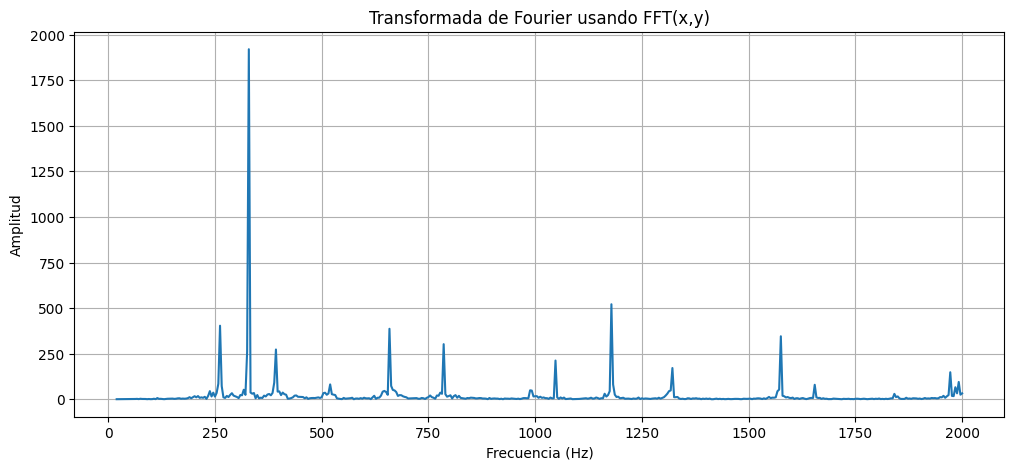

In [42]:
plt.figure(figsize=(12,5))
plt.plot(df['f'],df['AMP'])
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Transformada de Fourier usando FFT(x,y)")
plt.grid()

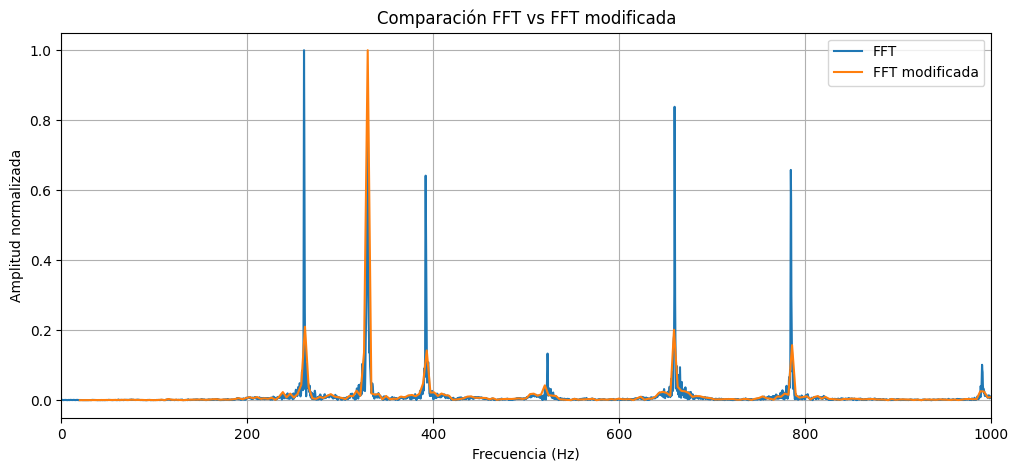

In [47]:
# COMPARACIÓN ENTRE FFT Y FFT MODIFICADA

plt.figure(figsize=(12,5))
plt.plot(
    freq[mask],
    np.abs(Y[mask])/np.max(np.abs(Y[mask])),
    label='FFT'
)
plt.plot(
    df['f'],
    df['AMP']/df['AMP'].max(),
    label='FFT modificada'
)
plt.xlim(0,1000)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud normalizada")
plt.title("Comparación FFT vs FFT modificada")
plt.legend()
plt.grid()

In [44]:
# FRECUENCIA PRINCIPAL OBTENIDA CON FFT
indice_fft = np.argmax(np.abs(Y[mask]))
print("Frecuencia principal FFT:")
print(freq[mask][indice_fft],"Hz")

Frecuencia principal FFT:
261.0085227272727 Hz


In [46]:
# FRECUENCIAS PRINCIPALES OBTENIDAS CON FFT MODIFICADA
print("Picos principales FFT modificada")

print(
    df.nlargest(
        10,
        'AMP'
    )[['f','AMP']]
)

Picos principales FFT modificada
               f          AMP
78    329.498998  1920.064563
292  1178.637275   521.134887
61    262.044088   403.479046
161   658.837675   386.674321
392  1575.430862   345.572008
193   785.811623   302.267525
94    392.985972   273.014759
77    325.531062   261.858673
259  1047.695391   212.494172
328  1321.482966   171.385535


##Conclusiones

La FFT de SciPy/NumPy y la FFT modificada presentan picos en las
mismas regiones del espectro de frecuencias.

Las componentes dominantes corresponden aproximadamente a las
notas Do, Mi y Sol del acorde de Do mayor contenido en el archivo
Sesiones_Fourier_Nota_CM_piano.mp3.

La FFT resulta mucho más rápida computacionalmente, mientras que
la FFT modificada reproduce el mismo comportamiento espectral a
partir de la definición de la Transformada de Fourier.